In [1]:
# 1️⃣ Kutubxonalarni chaqirish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [3]:
filtered_df = df[df[iris.feature_names[0]] > 4.5].copy()
X = filtered_df.drop('target', axis=1)

In [4]:
print("🔎 Filtrlangan dataset shakli:", X.shape)
print(filtered_df.head())

🔎 Filtrlangan dataset shakli: (145, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
eps = 0.7
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

In [7]:
unique_labels = set(labels)
print(f"\n✅ Klasterlar: {unique_labels}")
print(f"Shovqin nuqtalari soni (-1 klaster): {(labels == -1).sum()}")


✅ Klasterlar: {np.int64(0), np.int64(1), np.int64(-1)}
Shovqin nuqtalari soni (-1 klaster): 8


In [8]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

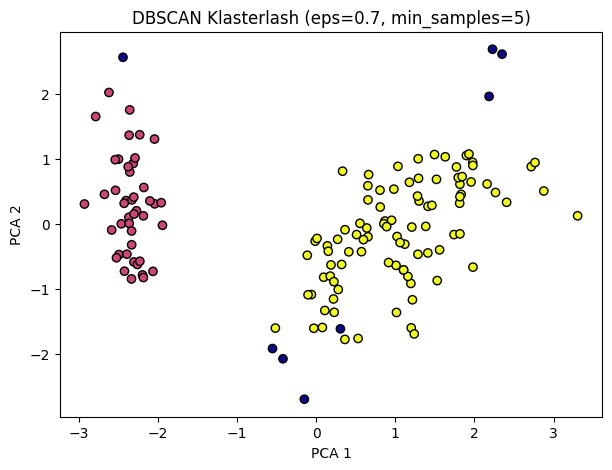

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='plasma', edgecolors='k')
plt.title(f"DBSCAN Klasterlash (eps={eps}, min_samples={min_samples})")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [10]:
clustered_df = filtered_df.copy()
clustered_df['Cluster'] = labels
summary = clustered_df.groupby('Cluster').mean()
print("\n📊 Klasterlar bo‘yicha o‘rtacha qiymatlar:")
print(summary)


📊 Klasterlar bo‘yicha o‘rtacha qiymatlar:
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
-1                6.037500          3.100000           4.412500   
 0                5.059091          3.468182           1.481818   
 1                6.275269          2.868817           4.911828   

         petal width (cm)    target  
Cluster                              
-1               1.475000  1.375000  
 0               0.247727  0.000000  
 1               1.679570  1.494624  


In [11]:
for new_eps in [0.5, 0.9, 1.2]:
    dbscan_alt = DBSCAN(eps=new_eps, min_samples=min_samples)
    labels_alt = dbscan_alt.fit_predict(X_scaled)
    unique_alt = set(labels_alt)
    print(f"\n🔧 eps={new_eps} uchun klasterlar: {unique_alt}, shovqinlar soni: {(labels_alt==-1).sum()}")


🔧 eps=0.5 uchun klasterlar: {np.int64(0), np.int64(1), np.int64(-1)}, shovqinlar soni: 33

🔧 eps=0.9 uchun klasterlar: {np.int64(0), np.int64(1), np.int64(-1)}, shovqinlar soni: 3

🔧 eps=1.2 uchun klasterlar: {np.int64(0), np.int64(1), np.int64(-1)}, shovqinlar soni: 1
